<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

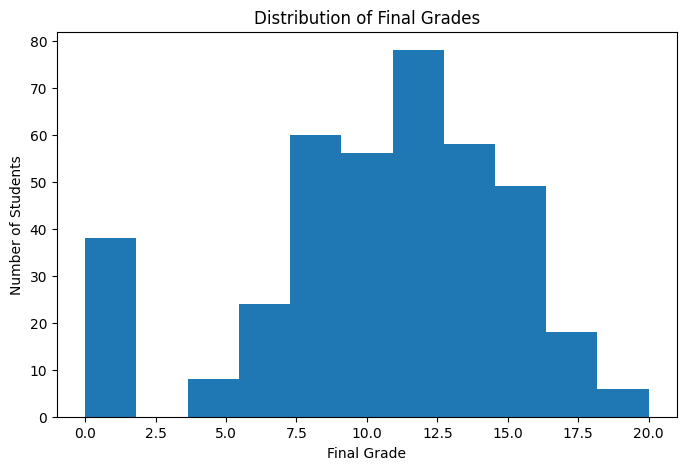

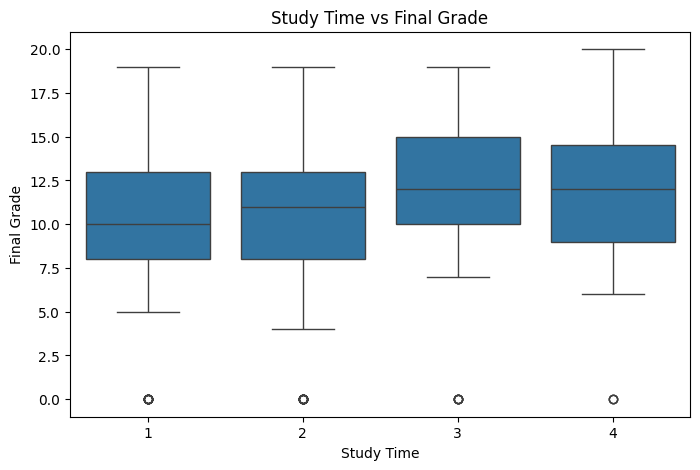

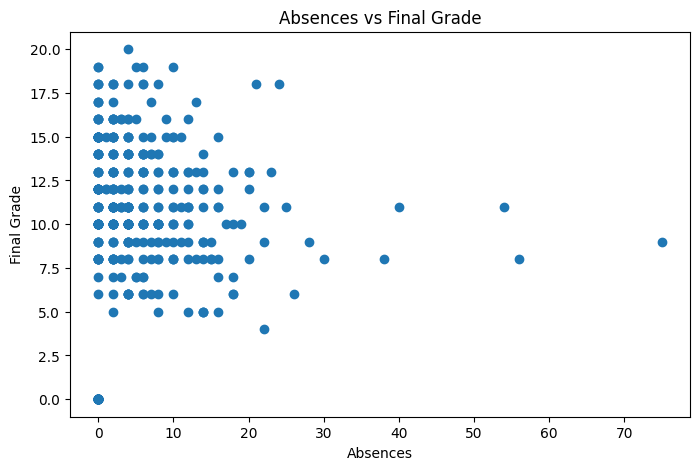

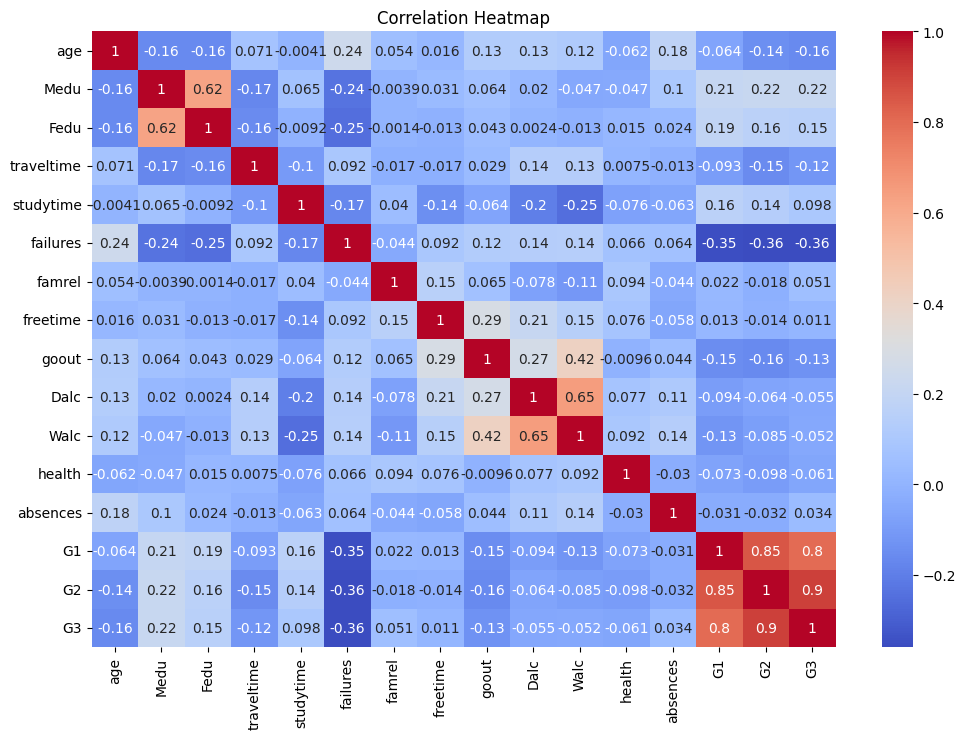

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
df = pd.read_csv("student-mat.csv", sep=";")
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
plt.figure(figsize=(8,5))

plt.hist(df["G3"], bins=11)

plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")

plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(x="studytime", y="G3", data=df)

plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Study Time vs Final Grade")

plt.show()
plt.figure(figsize=(8,5))

plt.scatter(df["absences"], df["G3"])

plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")

plt.show()
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()
X = df.drop("G3", axis=1)
y = df["G3"]
X = pd.get_dummies(X, drop_first=True)
X.head()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)


In [17]:
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression MAE:", linear_mae)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

print("Linear Regression RMSE:", linear_rmse)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 1.6466656197147511
Linear Regression RMSE: 2.3783697847961367
Linear Regression R²: 0.7241341236974022


In [18]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R²:", dt_r2)

Decision Tree MAE: 1.357218203737191
Decision Tree RMSE: 2.467248497769575
Decision Tree R²: 0.7031308891822728


In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=5
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 1.1615306677867305
Random Forest RMSE: 1.9468667645005289
Random Forest R²: 0.8151533059560585


In [20]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score": [
        linear_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.646666,2.378370,0.724134
1,Decision Tree,1.357218,2.467248,0.703131
2,Random Forest,1.161531,1.946867,0.815153


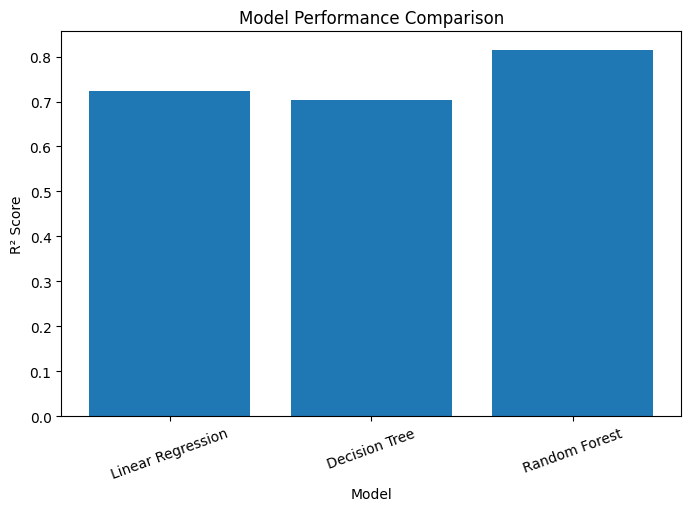

In [21]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.xticks(rotation=20)

plt.show()

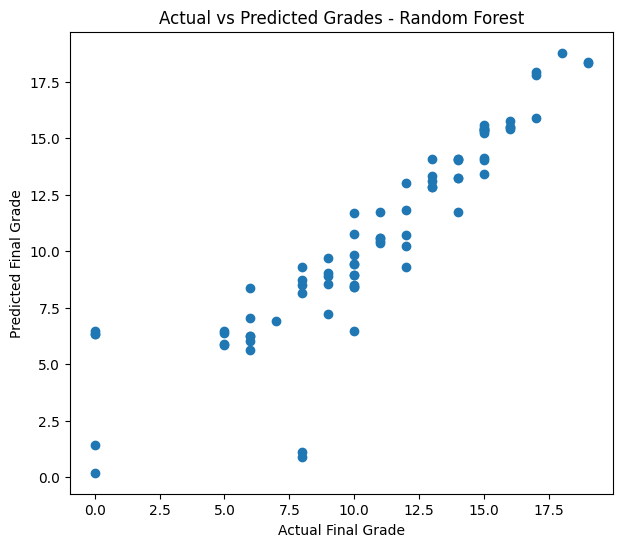

In [22]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Grades - Random Forest")

plt.show()

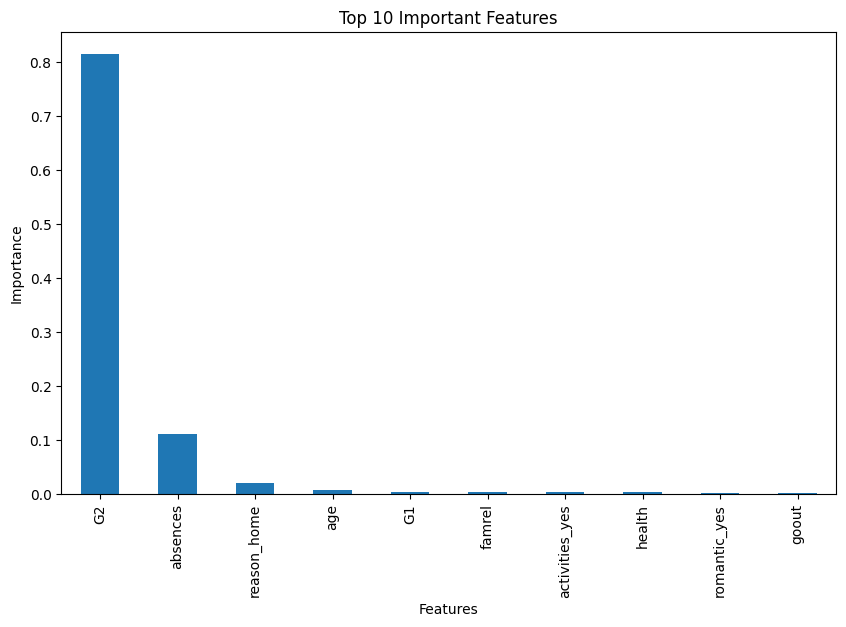

In [23]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Important Features")

plt.show()

In [26]:
df["Pass"] = (df["G3"] >= 10).astype(int)

In [31]:
X_class = df.drop(["G3", "Pass"], axis=1)

y_class = df["Pass"]
X_class = pd.get_dummies(X_class, drop_first=True)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [32]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)
rf_classifier.fit(X_train_c, y_train_c)
class_pred = rf_classifier.predict(X_test_c)
accuracy = accuracy_score(y_test_c, class_pred)

print("Classification Accuracy:", accuracy)

Classification Accuracy: 0.8734177215189873


In [33]:
print(classification_report(y_test_c, class_pred))

              precision    recall  f1-score   support

           0       0.75      0.92      0.83        26
           1       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79



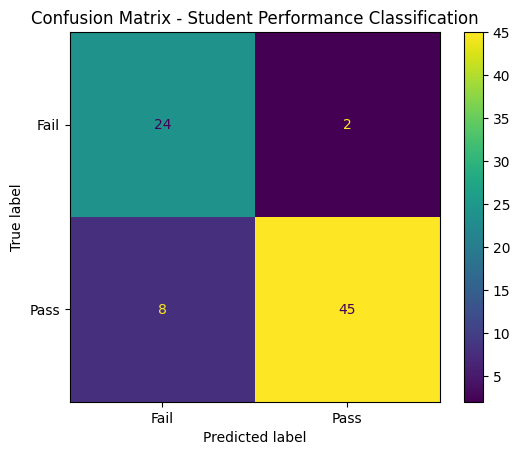

In [34]:
cm = confusion_matrix(y_test_c, class_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()

plt.title("Confusion Matrix - Student Performance Classification")

plt.show()

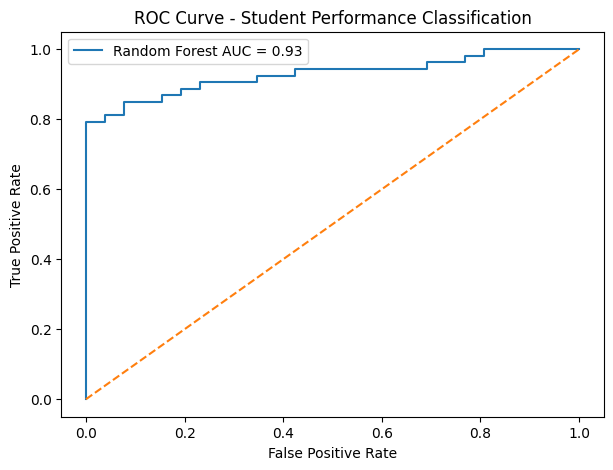

In [35]:
class_prob = rf_classifier.predict_proba(X_test_c)[:, 1]
fpr, tpr, thresholds = roc_curve(
    y_test_c,
    class_prob
)

auc_score = roc_auc_score(
    y_test_c,
    class_prob
)
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest AUC = {auc_score:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Student Performance Classification")

plt.legend()

plt.show()